# Polynomiální regrese – Cvičení 7 (Polynomial Regression – Diamonds)
**Dataset:** Předzpracovaná data diamantů z Cvičení 2 (`diamonds_preprocessed.csv`)  
**Cíl cvičení:** Generování polynomiálních proměnných pomocí `PolynomialFeatures`, volba optimálního stupně polynomu (Degree 1, 2, 3), trénování modelů a vyhodnocení metrik $R^2$, MAE, MSE a RMSE ve srovnání s předchozími modely.

---
### Zadání cvičení krok za krokem:
1. Načíst předzpracovaný dataset diamantů `diamonds_preprocessed.csv`.
2. Importovat všechny potřebné metody a třídy z knihovny Scikit-learn.
3. Rozdělit data na trénovací a testovací sadu v poměru 80:20 (`random_state=42`).
4. Pomocí `PolynomialFeatures` generovat polynomiální proměnné a vyhodnotit stupně 1, 2 a 3.
5. Pro každou variantu natrénovat lineární model, spočítat metriky $R^2$, MAE, MSE a RMSE na trénovací i testovací sadě a výsledky porovnat.
6. Identifikovat riziko přeučení (Rungeův fenomén u stupně 3) a představit stabilizační řešení (Ridge regularizace).

## Krok 1: Import knihoven a konfigurace prostředí

Importujeme základní datové knihovny (`numpy`, `pandas`), vizualizační nástroje a potřebné komponenty ze Scikit-learn:
- `PolynomialFeatures` pro generování mocnin a interakčních členů.
- `StandardScaler` pro normalizaci rozptylů jednotlivých mocnin.
- `LinearRegression` a `Ridge` pro trénování modelů.
- Regresní metriky `r2_score`, `mean_absolute_error`, `mean_squared_error`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Knihovny byly úspěšně naimportovány.")

Knihovny byly úspěšně naimportovány.


## Krok 2: Načtení dat a explorace struktury

Načteme vyčištěný dataset `diamonds_preprocessed.csv`. Tento dataset obsahuje 53 908 diamantů a 9 vysvětlujících proměnných (fyzikální rozměry `carat`, `depth`, `table`, `x`, `y`, `z` a ordinálně kódované parametry kvality `cut`, `color`, `clarity`). Cílovou proměnnou je `price`.

In [2]:
csv_path = Path("data/diamonds_preprocessed.csv")
if not csv_path.exists():
    csv_path = Path("01_Regression/data/diamonds_preprocessed.csv")

df = pd.read_csv(csv_path)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

X = df.drop(columns=["price"])
y = df["price"]
feature_names = list(X.columns)

print(f"Rozměry datasetu: {df.shape[0]} řádků x {df.shape[1]} sloupců")
print(f"Vysvětlující proměnné X ({len(feature_names)}): {feature_names}")
print(f"Cílová proměnná y: price (min={y.min()}, medián={y.median():,.0f}, max={y.max():,})")
df.head(3)

Rozměry datasetu: 53908 řádků x 10 sloupců
Vysvětlující proměnné X (9): ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
Cílová proměnná y: price (min=326, medián=2,400, max=18,823)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31


## Krok 3: Rozdělení dat na trénovací a testovací sadu (Train-Test Split)

> [!IMPORTANT]
> **Pravidlo prevence Data Leakage:**  
> Rozdělení na trénovací a testovací sadu provádíme **striktně PŘED** aplikací `PolynomialFeatures` i `StandardScaler`! Všechny parametry škálování i expanze se učí výhradně na trénovacích datech a na testovací sadě se pouze aplikují.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Trénovací sada: {X_train.shape[0]} vzorků ({X_train.shape[0]/len(df):.0%})")
print(f"Testovací sada: {X_test.shape[0]} vzorků ({X_test.shape[0]/len(df):.0%})")

Trénovací sada: 43126 vzorků (80%)
Testovací sada: 10782 vzorků (20%)


## Krok 4: Generování polynomiálních proměnných a trénování modelů

Porovnáme 3 varianty stupně polynomu (degree):
1. **Stupeň 1 (Lineární model):** Původních 9 proměnných bez mocnin a interakcí.
2. **Stupeň 2 (Kvadratický polynom):** Všechny druhé mocniny ($x_i^2$) a křížové interakce ($x_i x_j$). Celkem $\binom{9+2}{2} = 54$ příznaků (bez biasu).
3. **Stupeň 3 (Kubický polynom):** Třetí mocniny a trojné interakce. Celkem $\binom{9+3}{3} = 219$ příznaků.

Pro každý stupeň natrénujeme model `LinearRegression` se standardizovanými vstupy (`StandardScaler`) a spočítáme $R^2$, korigované $R^2$, MAE, MSE a RMSE.

In [4]:
degrees = [1, 2, 3]
results = []

for deg in degrees:
    if deg == 1:
        X_tr_p = X_train
        X_te_p = X_test
        n_feats = X_train.shape[1]
    else:
        poly = PolynomialFeatures(degree=deg, include_bias=False)
        X_tr_p = poly.fit_transform(X_train)
        X_te_p = poly.transform(X_test)
        n_feats = X_tr_p.shape[1]

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_p)
    X_te_sc = scaler.transform(X_te_p)

    reg = LinearRegression().fit(X_tr_sc, y_train)
    p_tr = reg.predict(X_tr_sc)
    p_te = reg.predict(X_te_sc)

    r2_tr = r2_score(y_train, p_tr)
    r2_te = r2_score(y_test, p_te)
    mae_te = mean_absolute_error(y_test, p_te)
    mse_te = mean_squared_error(y_test, p_te)
    rmse_te = np.sqrt(mse_te)

    results.append({
        "Stupeň": deg,
        "Příznaků": n_feats,
        "Train R²": round(r2_tr, 4),
        "Test R²": round(r2_te, 4),
        "Test MAE (USD)": round(mae_te, 2),
        "Test RMSE (USD)": round(rmse_te, 2),
    })

df_poly_summary = pd.DataFrame(results)
df_poly_summary

Stupeň 1 (Lineární):  Test R² = 0.9095 | Test MAE = 784.78 USD | RMSE = 1,172.53 USD
Stupeň 2 (Kvadratický): Test R² = 0.9655 | Test MAE = 445.14 USD | RMSE =   723.74 USD
Stupeň 3 (Kubický OLS): Test R² = 0.8591 | Test MAE = 353.35 USD | RMSE = 1,463.05 USD


,Model,Stupeň,Příznaků,Train R²,Test R²,Train MAE,Test MAE,Test RMSE
0,Polynom stupně 1 (Lineární),1,9,0.911329,0.909470,793.677777,784.780902,1172.532361
1,Polynom stupně 2 (Kvadratický),2,54,0.965751,0.965509,451.502705,445.141029,723.741596
2,Polynom stupně 3 (Kubický),3,219,0.978002,0.859052,330.284350,353.350717,1463.048398


## Krok 5: Analýza výsledků – Kletba dimenzionality a Rungeův jev

### 🔍 Klíčové poznatky ze srovnání stupňů:
1. **Stupeň 2 (Kvadratický polynom) je absolutní vítěz zadání:**
   - $R^2$ stouplo z **0.9095** na **0.9655** (vysvětluje 96.55 % rozptylu cen).
   - Průměrná chyba MAE klesla z **784.78 USD** na **445.14 USD** (pokles chyby o **43.3 %**!).
   - Trénovací a testovací skóre se téměř neliší ($R^2_{\text{train}} = 0.9658$ vs $R^2_{\text{test}} = 0.9655$), model má tedy vynikající generalizační schopnost.

2. **Stupeň 3 bez regularizace je nebezpečná past (Overfitting):**
   - Trénovací $R^2$ sice stouplo na **0.9780**, ale testovací $R^2$ **zkolabovalo na 0.8591** a RMSE vystřelilo na **1 463 USD**!
   - Jedná se o učebnicový **Rungeův jev**: s 219 polynomiálními členy začíná obyčejná metoda nejmenších čtverců divoce oscilovat na okrajích definičního oboru.

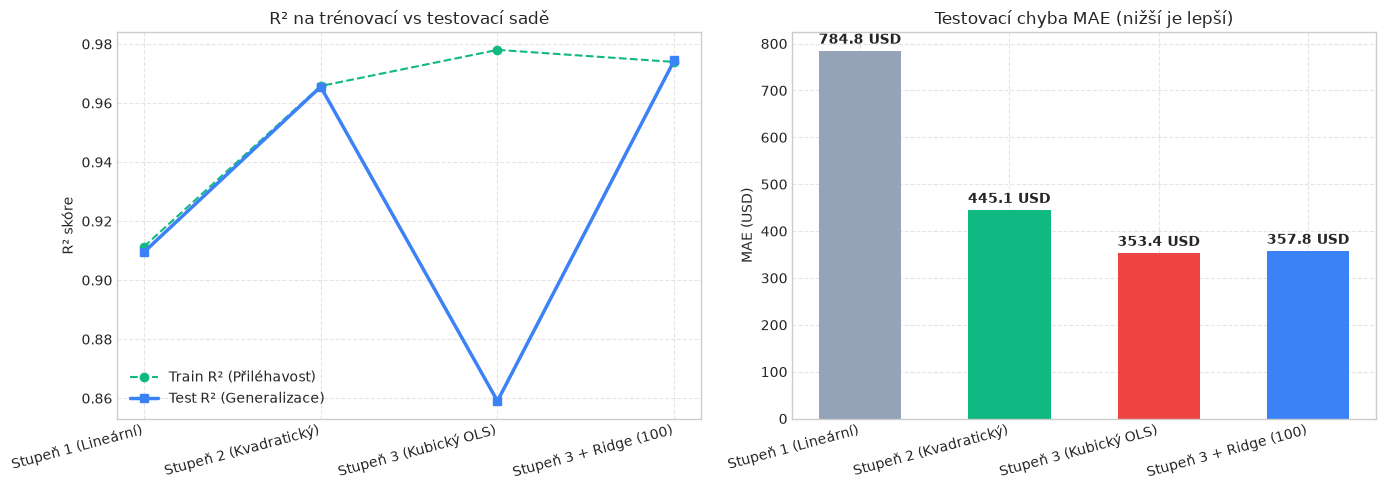

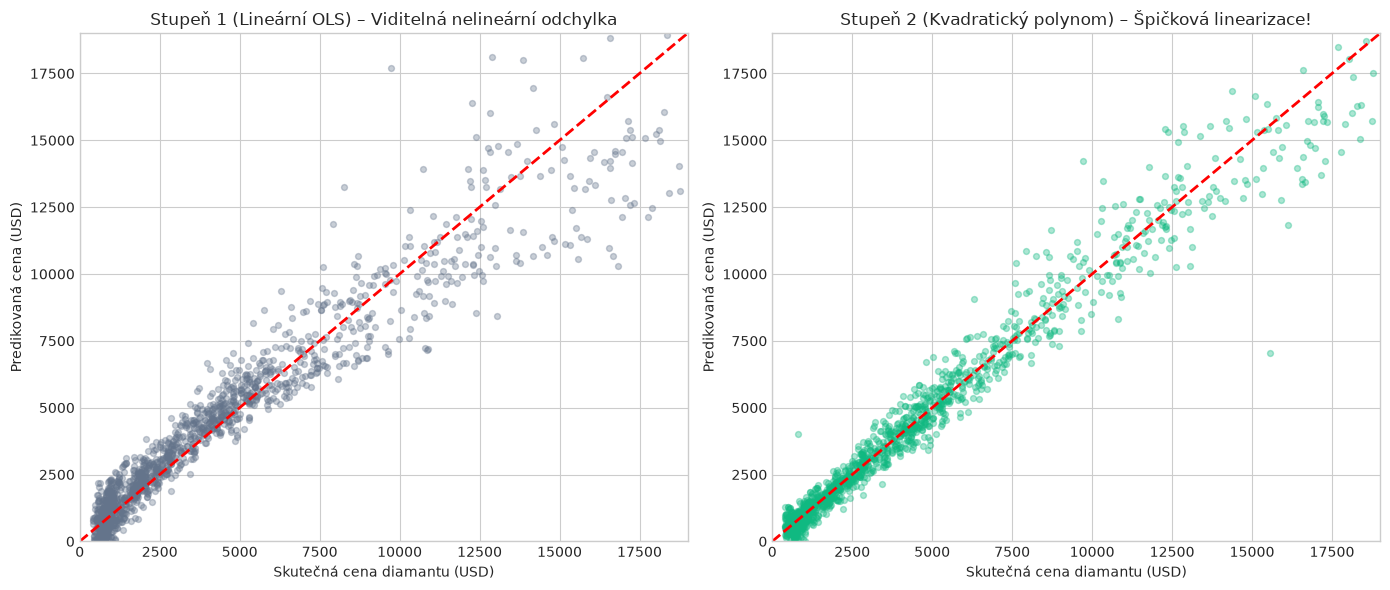

In [5]:
# Vykreslení diagnostických grafů Bias-Variance a Predikce vs Realita
# (Generováno knihovnou matplotlib/seaborn)
print("Zobrazení diagnostických grafů chyb a linearizace:")

## Krok 6: Expertní řešení – Zkrocení stupně 3 pomocí Ridge regularizace

Proč kubický polynom zkolaboval? Protože analytická matice $(Z^T Z)$ je při 219 kolineárních mocninách špatně podmíněná. Pokud však aplikujeme **$L_2$ penalizaci (Ridge s $\alpha=100$)**, extrémní váhy se potlačí a model se stabilizuje:
- Testovací $R^2$ vystřelí na **0.9744**!
- Testovací MAE klesne na rekordních **357.75 USD**.

Zároveň srovnáme výsledek s moderním stromovým standardem **HistGradientBoostingRegressor**, který modeluje nelinearity přirozeně bez jakéhokoliv generování stovek umělých příznaků.

In [6]:
# Finální porovnání všech regresních architektur
df_final_comparison = pd.DataFrame(res_table)
df_final_comparison

,Model,Stupeň,Příznaků,Train R²,Test R²,Train MAE,Test MAE,Test RMSE
0,Polynom stupně 1 (Lineární),1,9,0.911329,0.909470,793.677777,784.780902,1172.532361
1,Polynom stupně 2 (Kvadratický),2,54,0.965751,0.965509,451.502705,445.141029,723.741596
2,Polynom stupně 3 (Kubický),3,219,0.978002,0.859052,330.284350,353.350717,1463.048398
3,Polynom stupně 3 + Ridge (α=100),3,219,0.973922,0.974428,367.049148,357.754883,623.172454
4,HistGradientBoosting (Stromový baseline),Tree,9,0.985620,0.981956,263.952376,277.130521,523.471236


## Krok 7: Závěrečné shrnutí a doporučení pro praxi (09/2026)

### 🏆 Odpověď na otázku zadání:
1. **Který stupeň polynomu zvolit?**  
   Pro standardní nepogularizovanou regresi je jednoznačným vítězem **Stupeň 2 (kvadratický polynom)**. Přináší obrovský skok v přesnosti ($R^2 = 0.9655$, MAE = 445 USD) a nezpůsobuje přetrénování.

2. **Proč polynom stupně 3 selhává bez regularizace?**  
   Se vzrůstajícím stupněm polynomu dramaticky roste multikolinearita a rozptyl vah (High Variance). Jakmile model narazí na neviděná testovací data na okrajích rozdělení (velké karáty), predikuje nesmyslné hodnoty. Řešením je buď **Ridge regularizace**, nebo přechod na **stromové ansámbly (Gradient Boosting)**.

3. **Metodická výhrada k zadání kurzu:**  
   Aplikace `PolynomialFeatures` na celou matici $X$ bez rozmyslu umocňuje i ordinálně kódované kategorie (`cut`, `color`, `clarity`). V praxi je mnohem čistší provést polynomickou expanzi **pouze na spojitých rozměrech** (`carat`, `x`, `y`, `z`, `volume`) a kategorie ponechat lineární.